# Feature-Based Strategy (v3)

**Why not Chronos?** EDA shows 2nd-half returns have a positive drift (~+0.35% mean). Chronos was taking short positions against this drift → Sharpe -0.76. Always-long already gets Sharpe ≈ +2.77.

**Strategy** (data-backed from EDA + Igor's analysis):
1. **Lag-25 autocorrelation** of log-returns: the strongest directional signal found (Igor: top/bottom sessions → Sharpe +4.20)
2. **Garman-Klass volatility**: predicts magnitude (r=0.25 with |return|); vol persists strongly (r=0.74 1st→2nd half)
3. **Long bias**: default to long — the drift is real, shorting blindly destroys value
4. **Sentiment tilt**: small secondary signal from FinBERT linear_score

In [14]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Python:', sys.executable)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

Python: /Users/iliasmc/projects/hrt-datathon/.venv/bin/python
pandas: 2.3.3
numpy: 2.4.4


In [15]:
DATA_DIR  = '../data'
ANNA_DIR  = '../anna'
OUT_DIR   = '.'

MAX_POSITION     = 1.0
AC25_LONG_THRESH  = 0.40   # top ~30% of sessions by autocorr → aggressive long
AC25_SHORT_THRESH = -0.40  # bottom ~20% → partial short
SENTIMENT_WEIGHT  = 0.05   # small tilt; EDA shows near-zero linear correlation

## Load data

In [16]:
train_seen   = pd.read_parquet(f'{DATA_DIR}/bars_seen_train.parquet')
train_unseen = pd.read_parquet(f'{DATA_DIR}/bars_unseen_train.parquet')
public_seen  = pd.read_parquet(f'{DATA_DIR}/bars_seen_public_test.parquet')
private_seen = pd.read_parquet(f'{DATA_DIR}/bars_seen_private_test.parquet')

for df, name in [(train_seen,'train_seen'),(train_unseen,'train_unseen'),
                  (public_seen,'public_seen'),(private_seen,'private_seen')]:
    print(f'{name}: {df.shape}  sessions {df.session.min()}–{df.session.max()}')

train_seen: (50000, 6)  sessions 0–999
train_unseen: (50000, 6)  sessions 0–999
public_seen: (500000, 6)  sessions 1000–10999
private_seen: (500000, 6)  sessions 11000–20999


## Feature engineering

In [17]:
def compute_features(bars_df):
    """
    Per-session features from the seen 50 bars:
    - ac25:          lag-25 autocorrelation of log-returns (directional signal)
    - gk_vol:        Garman-Klass volatility estimate (magnitude signal)
    - ret_1h:        1st-half return open→close (near-zero predictive power; kept for diagnostics)
    - close_in_range: where does the final close sit in the seen H-L band (0=low, 1=high)
    """
    bars_df = bars_df.sort_values(['session', 'bar_ix'])

    def _session_features(grp):
        c   = grp['close'].values
        lr  = np.diff(np.log(c))            # 49 log-returns

        # Lag-25 autocorrelation (24 pairs)
        if len(lr) > 25:
            r1, r2 = lr[:-25], lr[25:]
            ac25 = float(np.corrcoef(r1, r2)[0, 1])
            if not np.isfinite(ac25):
                ac25 = 0.0
        else:
            ac25 = 0.0

        # Garman-Klass variance: 0.5*(ln H/L)^2 - (2ln2-1)*(ln C/O)^2
        ln_hl = np.log(grp['high'].values / grp['low'].values)
        ln_co = np.log(grp['close'].values / grp['open'].values)
        gk_var = 0.5 * ln_hl**2 - (2 * np.log(2) - 1) * ln_co**2
        gk_vol = float(np.sqrt(np.maximum(gk_var, 0).mean()))

        # 1st-half return
        ret_1h = float(c[-1] / c[0] - 1)

        # Close position within H-L range
        h_max = grp['high'].max()
        l_min = grp['low'].min()
        close_in_range = float((c[-1] - l_min) / (h_max - l_min + 1e-10))

        return pd.Series({'ac25': ac25, 'gk_vol': gk_vol,
                          'ret_1h': ret_1h, 'close_in_range': close_in_range})

    return bars_df.groupby('session').apply(_session_features)

In [18]:
print('Computing training features...')
feat_train = compute_features(train_seen)
display(feat_train.describe().round(4))

Computing training features...


/var/folders/1x/3yzs3rmd6bg8zvlc0df6zn_40000gn/T/ipykernel_28099/2047672099.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return bars_df.groupby('session').apply(_session_features)


,ac25,gk_vol,ret_1h,close_in_range
count,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.0120,0.0024,0.0018,0.5147
std,0.2205,0.0004,0.0208,0.3192
min,-0.6387,0.0016,-0.0672,0.0000
25%,-0.1357,0.0020,-0.0120,0.2221
50%,0.0076,0.0024,0.0018,0.5265
75%,0.1652,0.0028,0.0153,0.8118
max,0.7149,0.0034,0.0727,1.0000


## Load sentiment (secondary tilt)

In [19]:
def load_sentiment(csv_path):
    """Mean FinBERT linear_score per session across all seen bars."""
    s = pd.read_csv(csv_path, usecols=['session', 'linear_score'])
    return s.groupby('session')['linear_score'].mean().rename('sentiment')

sent_train   = load_sentiment(f'{ANNA_DIR}/headline_stats_seen_train.csv')
sent_public  = load_sentiment(f'{ANNA_DIR}/headline_stats_seen_pubtest.csv')
sent_private = load_sentiment(f'{ANNA_DIR}/headline_stats_seen_privtest.csv')

feat_train = feat_train.join(sent_train).fillna({'sentiment': 0.0})
print(f'Train features shape: {feat_train.shape}')
display(feat_train.head(3))

Train features shape: (1000, 5)


,ac25,gk_vol,ret_1h,close_in_range,sentiment
session,,,,,
0,-0.267418,0.002378,0.031703,0.940171,0.272358
1,-0.226448,0.002749,0.027470,0.738983,-0.059515
2,0.008951,0.003004,0.025208,0.873720,-0.151299


## Baseline evaluation on training set

In [20]:
close_halfway = train_seen.groupby('session')['close'].last().rename('close_halfway')
close_end     = train_unseen.groupby('session')['close'].last().rename('close_end')
actual_ret    = (close_end / close_halfway - 1).rename('return_2h')

def sharpe(positions, returns, scale=16):
    pnl = np.asarray(positions) * np.asarray(returns)
    return float(np.mean(pnl) / np.std(pnl) * scale) if np.std(pnl) > 0 else 0.0

feat_eval = feat_train.join(actual_ret)

# Baselines
mean_gk_vol = feat_train['gk_vol'].mean()
inv_vol_pos = (mean_gk_vol / feat_train['gk_vol']).clip(0.5, 1.5).reindex(feat_eval.index)

print(f'Always long (+1):          Sharpe = {sharpe(np.ones(1000), actual_ret):.4f}')
print(f'Always long (inv-vol):     Sharpe = {sharpe(inv_vol_pos, actual_ret):.4f}')
print(f'Correlation ac25→return:  r = {feat_eval["ac25"].corr(feat_eval["return_2h"]):.4f}')
print(f'Correlation vol→|return|: r = {feat_eval["gk_vol"].corr(feat_eval["return_2h"].abs()):.4f}')

Always long (+1):          Sharpe = 2.7661
Always long (inv-vol):     Sharpe = 2.6586
Correlation ac25→return:  r = -0.0048
Correlation vol→|return|: r = 0.2516


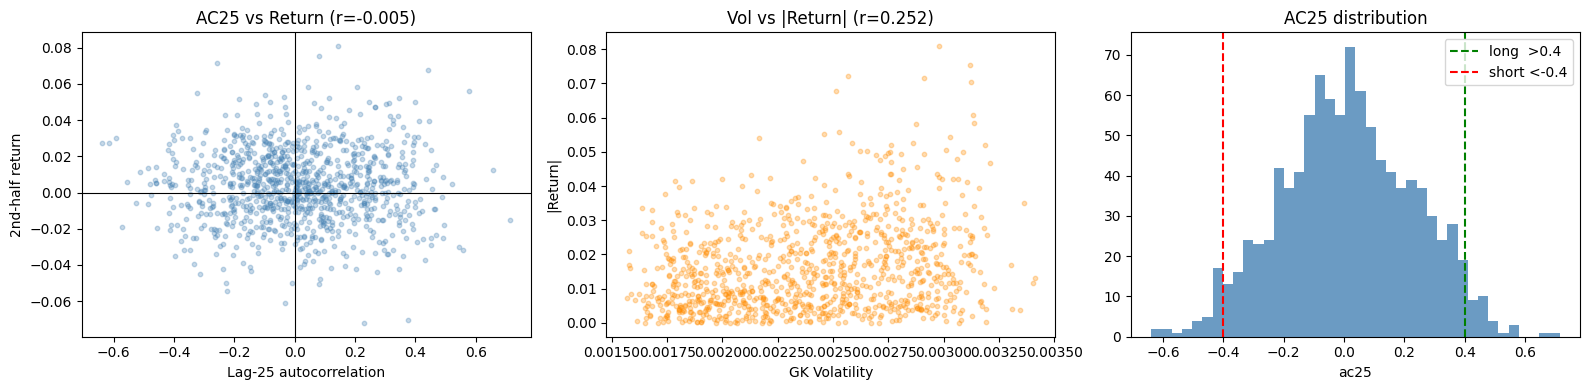


2nd-half return by autocorr regime:


/var/folders/1x/3yzs3rmd6bg8zvlc0df6zn_40000gn/T/ipykernel_28099/1823503773.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_stats = feat_eval.groupby('regime')['return_2h'].agg(['mean', 'std', 'count'])


,mean,std,count
regime,,,
short (ac25<-0.4),0.0062,0.0148,33
neutral (-0.4 to 0.4),0.0035,0.0204,936
long (ac25>0.4),0.0004,0.0271,31


In [21]:
# Diagnostic: ac25 vs return and vol vs |return|
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(feat_eval['ac25'], feat_eval['return_2h'], alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='k', lw=0.8); axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('Lag-25 autocorrelation'); axes[0].set_ylabel('2nd-half return')
r = feat_eval['ac25'].corr(feat_eval['return_2h'])
axes[0].set_title(f'AC25 vs Return (r={r:.3f})')

axes[1].scatter(feat_eval['gk_vol'], feat_eval['return_2h'].abs(), alpha=0.3, s=10, color='darkorange')
rv = feat_eval['gk_vol'].corr(feat_eval['return_2h'].abs())
axes[1].set_xlabel('GK Volatility'); axes[1].set_ylabel('|Return|')
axes[1].set_title(f'Vol vs |Return| (r={rv:.3f})')

axes[2].hist(feat_eval['ac25'], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].axvline(AC25_LONG_THRESH,  color='green', lw=1.5, linestyle='--', label=f'long  >{AC25_LONG_THRESH}')
axes[2].axvline(AC25_SHORT_THRESH, color='red',   lw=1.5, linestyle='--', label=f'short <{AC25_SHORT_THRESH}')
axes[2].set_xlabel('ac25'); axes[2].set_title('AC25 distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

# Show mean 2nd-half return by ac25 regime
feat_eval['regime'] = pd.cut(
    feat_eval['ac25'],
    bins=[-1, AC25_SHORT_THRESH, AC25_LONG_THRESH, 1],
    labels=['short (ac25<-0.4)', 'neutral (-0.4 to 0.4)', 'long (ac25>0.4)']
)
regime_stats = feat_eval.groupby('regime')['return_2h'].agg(['mean', 'std', 'count'])
print('\n2nd-half return by autocorr regime:')
display(regime_stats.round(4))

## Position sizing function

In [22]:
def make_submission(feat_df, mean_gk_vol_ref=None):
    """
    Build target_position from session features.

    Position logic:
      1. Inverse-vol scale (normalize risk across sessions)
      2. Three regimes based on lag-25 autocorrelation:
         - ac25 > +0.40  → full long  (strong momentum continuation)
         - ac25 < -0.40  → half short (strong reversal, conservative)
         - otherwise     → 80% long   (default — capture the positive drift)
      3. Small sentiment tilt on top
    """
    df = feat_df.copy()
    ref_vol = mean_gk_vol_ref if mean_gk_vol_ref is not None else df['gk_vol'].mean()

    df['inv_vol'] = (ref_vol / df['gk_vol'].clip(lower=ref_vol * 0.3)).clip(upper=1.5)

    # Regime direction
    df['base_pos'] = np.where(
        df['ac25'] > AC25_LONG_THRESH,
        df['inv_vol'],                    # full long
        np.where(
            df['ac25'] < AC25_SHORT_THRESH,
            -df['inv_vol'] * 0.5,         # half short
            df['inv_vol'] * 0.8           # default long
        )
    )

    # Sentiment tilt
    if 'sentiment' in df.columns:
        df['base_pos'] += df['sentiment'].fillna(0.0) * SENTIMENT_WEIGHT

    df['target_position'] = df['base_pos'].clip(-MAX_POSITION, MAX_POSITION)

    return (
        df[['target_position']]
        .reset_index()[['session', 'target_position']]
        .sort_values('session')
    )

## Train evaluation

Long: 967  Short: 33  Flat: 0

Sharpe: 2.4697
Mean PnL: 0.002473  Std PnL: 0.016024
Win rate: 55.70%


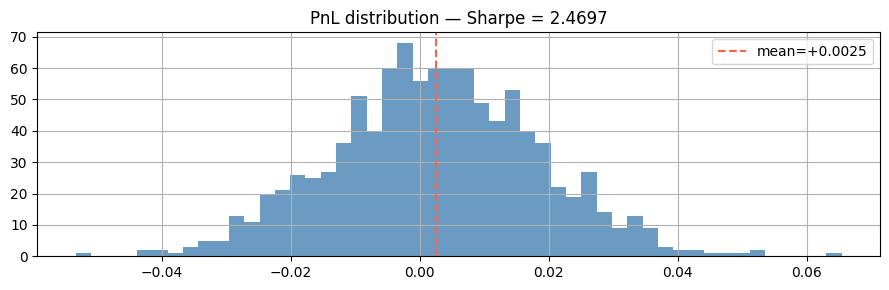

In [23]:
mean_gk_vol_train = feat_train['gk_vol'].mean()
submission_train  = make_submission(feat_train, mean_gk_vol_ref=mean_gk_vol_train)

n_long  = (submission_train['target_position'] > 0).sum()
n_short = (submission_train['target_position'] < 0).sum()
print(f'Long: {n_long}  Short: {n_short}  Flat: {1000 - n_long - n_short}')

eval_df = submission_train.set_index('session').join(close_halfway).join(close_end)
eval_df['pnl'] = eval_df['target_position'] * (eval_df['close_end'] / eval_df['close_halfway'] - 1)

sharpe_v3 = eval_df['pnl'].mean() / eval_df['pnl'].std() * 16
win_rate  = (eval_df['pnl'] > 0).mean()
print(f'\nSharpe: {sharpe_v3:.4f}')
print(f'Mean PnL: {eval_df["pnl"].mean():.6f}  Std PnL: {eval_df["pnl"].std():.6f}')
print(f'Win rate: {win_rate:.2%}')

fig, ax = plt.subplots(figsize=(9, 3))
eval_df['pnl'].hist(bins=50, ax=ax, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(eval_df['pnl'].mean(), color='tomato', linestyle='--', label=f'mean={eval_df["pnl"].mean():+.4f}')
ax.set_title(f'PnL distribution — Sharpe = {sharpe_v3:.4f}')
ax.legend(); plt.tight_layout(); plt.show()

## Test set submissions

In [24]:
print('Computing public features...')
feat_public = compute_features(public_seen)
feat_public = feat_public.join(sent_public).fillna({'sentiment': 0.0})

submission_public = make_submission(feat_public, mean_gk_vol_ref=mean_gk_vol_train)
n_long  = (submission_public['target_position'] > 0).sum()
n_short = (submission_public['target_position'] < 0).sum()
print(f'Public: {len(submission_public)} sessions — long={n_long}, short={n_short}, flat={len(submission_public)-n_long-n_short}')
display(submission_public.describe())

Computing public features...
Public: 10000 sessions — long=9719, short=281, flat=0


/var/folders/1x/3yzs3rmd6bg8zvlc0df6zn_40000gn/T/ipykernel_28099/2047672099.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return bars_df.groupby('session').apply(_session_features)


,session,target_position
count,10000.00000,10000.000000
mean,5999.50000,0.786139
std,2886.89568,0.256168
min,1000.00000,-0.737769
25%,3499.75000,0.699592
50%,5999.50000,0.808926
75%,8499.25000,0.954130
max,10999.00000,1.000000


In [25]:
print('Computing private features...')
feat_private = compute_features(private_seen)
feat_private = feat_private.join(sent_private).fillna({'sentiment': 0.0})

submission_private = make_submission(feat_private, mean_gk_vol_ref=mean_gk_vol_train)
n_long  = (submission_private['target_position'] > 0).sum()
n_short = (submission_private['target_position'] < 0).sum()
print(f'Private: {len(submission_private)} sessions — long={n_long}, short={n_short}, flat={len(submission_private)-n_long-n_short}')
display(submission_private.describe())

Computing private features...
Private: 10000 sessions — long=9715, short=285, flat=0


/var/folders/1x/3yzs3rmd6bg8zvlc0df6zn_40000gn/T/ipykernel_28099/2047672099.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return bars_df.groupby('session').apply(_session_features)


,session,target_position
count,10000.00000,10000.000000
mean,15999.50000,0.784753
std,2886.89568,0.259060
min,11000.00000,-0.742520
25%,13499.75000,0.698120
50%,15999.50000,0.807222
75%,18499.25000,0.953786
max,20999.00000,1.000000


In [26]:
submission_combined = pd.concat([submission_public, submission_private], ignore_index=True)

assert len(submission_combined) == 20000
assert submission_combined['session'].nunique() == 20000
assert submission_combined['session'].min() == 1000
assert submission_combined['session'].max() == 20999
assert (submission_combined['target_position'].abs() <= MAX_POSITION + 1e-9).all()

PUBLIC_CSV   = f'{OUT_DIR}/submission_v3_public.csv'
PRIVATE_CSV  = f'{OUT_DIR}/submission_v3_private.csv'
COMBINED_CSV = f'{OUT_DIR}/submission_v3_combined.csv'

submission_public.to_csv(PUBLIC_CSV, index=False)
submission_private.to_csv(PRIVATE_CSV, index=False)
submission_combined.to_csv(COMBINED_CSV, index=False)

print(f'Saved {PUBLIC_CSV}   ({len(submission_public)} rows)')
print(f'Saved {PRIVATE_CSV}  ({len(submission_private)} rows)')
print(f'Saved {COMBINED_CSV} ({len(submission_combined)} rows)')
display(submission_combined.head(5))
display(submission_combined.tail(5))

Saved ./submission_v3_public.csv   (10000 rows)
Saved ./submission_v3_private.csv  (10000 rows)
Saved ./submission_v3_combined.csv (20000 rows)


,session,target_position
0,1000,1.000000
1,1001,1.000000
2,1002,1.000000
3,1003,1.000000
4,1004,0.828458


,session,target_position
19995,20995,0.800432
19996,20996,1.000000
19997,20997,0.793500
19998,20998,0.832165
19999,20999,0.806156
